In [79]:
import pandas as pd
import glob
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
######Here we will look at some ways of modelling tennis matches. Monte-Carlo simulation, Logistic regression, Markov chain based
# on ELO scores, and Logistic regression (based on several features) + Markov chain
# -----------------------------
# Step 1: Load CSVs
# -----------------------------
folder = '/Users/lukepiper/Documents/Tennis CSVs'
def load_data(folder):
    df = pd.concat(
        (pd.read_csv(f) for f in glob.glob(os.path.join(folder, '*.csv'))),
        ignore_index=True
    )
    df['tourney_date'] = pd.to_datetime(df['tourney_date'], format='%Y%m%d', errors='coerce')
    return df.sort_values('tourney_date')

df_matches = load_data(folder)

split_index = int(len(df_matches) * 0.8)

df_train = df_matches.iloc[:split_index].reset_index(drop=True)
df_test = df_matches.iloc[split_index:].reset_index(drop=True)


In [81]:
### Logistic regression with player aggregate player stats (add time decay like Dixon-Coles???????) ######

In [83]:
# -----------------------------
# Step 2: Compute player-level stats
# -----------------------------
def compute_player_stats(df):
    players = []

    # Winner stats
    w_cols = ['winner_name','w_ace','w_df','w_1stIn','w_1stWon','w_2ndWon','w_svpt','w_SvGms']
    w_df = df[w_cols].copy()
    w_df.rename(columns={'winner_name':'player',
                         'w_ace':'ace','w_df':'df',
                         'w_1stIn':'first_in','w_1stWon':'first_won',
                         'w_2ndWon':'second_won','w_svpt':'total_serves',
                         'w_SvGms':'service_games'}, inplace=True)
    w_df['role'] = 'winner'

    # Loser stats
    l_cols = ['loser_name','l_ace','l_df','l_1stIn','l_1stWon','l_2ndWon','l_svpt','l_SvGms']
    l_df = df[l_cols].copy()
    l_df.rename(columns={'loser_name':'player',
                         'l_ace':'ace','l_df':'df',
                         'l_1stIn':'first_in','l_1stWon':'first_won',
                         'l_2ndWon':'second_won','l_svpt':'total_serves',
                         'l_SvGms':'service_games'}, inplace=True)
    l_df['role'] = 'loser'

    # Combine
    all_players = pd.concat([w_df, l_df], ignore_index=True)

    # Aggregate per player
    player_stats = all_players.groupby('player').agg(
        total_matches=('total_serves','count'),
        ace_rate=('ace','sum'), ## Ace rate
        df_rate=('df','sum'), ## Double fault rate
        first_in_total=('first_in','sum'), #Total first serves IN
        first_won_total=('first_won','sum'), #Points won on first serve
        second_won_total=('second_won','sum'), # Points won on second serve
        total_serves=('total_serves','sum'), # Total serves
        service_games=('service_games','sum')
    )

    # Compute percentages
    player_stats['ace_pct'] = player_stats['ace_rate'] / player_stats['total_serves'] #How often will they get an ace?
    player_stats['df_pct'] = player_stats['df_rate'] / player_stats['total_serves'] #How often will they double fault?
    player_stats['first_in_pct'] = player_stats['first_in_total'] / player_stats['total_serves']
    player_stats['first_won_pct'] = player_stats['first_won_total'] / player_stats['first_in_total']
    player_stats['second_won_pct'] = player_stats['second_won_total'] / (player_stats['total_serves'] - player_stats['first_in_total'])
    player_stats.fillna(0, inplace=True)

    return player_stats

In [85]:
# -----------------------------
# Step 3: Build match-level dataset
# -----------------------------
def build_match_features(df, player_stats):
    features = []
    for _, row in df.iterrows():
        winner = row['winner_name']
        loser = row['loser_name']

        if winner not in player_stats.index or loser not in player_stats.index:
            continue  # skip if stats missing

        # Feature differences (winner - loser)
        feat = {}
        for col in ['ace_pct','df_pct','first_in_pct','first_won_pct','second_won_pct']:
            feat[f'{col}_diff'] = player_stats.loc[winner,col] - player_stats.loc[loser,col]

        feat['winner'] = 1  # target
        features.append(feat)

        # Also add the reverse for balance (loser perspective)
        rev_feat = {k.replace('_diff','_diff'): -v for k,v in feat.items() if k != 'winner'}
        rev_feat['winner'] = 0
        features.append(rev_feat)

    feature_df = pd.DataFrame(features)
    feature_df.dropna(inplace=True)
    return feature_df



In [87]:
# -----------------------------
# Step 4: Train baseline model
# -----------------------------
def train_baseline_model(X_train, y_train):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)

    return model, scaler

In [89]:


# Prepare data
X_train = match_features_train.drop(columns=['winner'])
y_train = match_features_train['winner']

X_test = match_features_test.drop(columns=['winner'])
y_test = match_features_test['winner']

# Train
model, scaler = train_baseline_model(X_train, y_train)

# Evaluate
X_test_scaled = scaler.transform(X_test)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:,1]
print('Logistic regression evaluation:')
print('Test Accuracy:', accuracy_score(y_test, y_pred))
print('Test ROC AUC:', roc_auc_score(y_test, y_proba))

Logistic regression evaluation:
Test Accuracy: 0.5853116756906844
Test ROC AUC: 0.6204011783465437


In [ ]:
## Markov model with purely Elo. We assume point level probability is given by p^1/4

In [91]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss

# -----------------------------
# Step 1: Train/Test Split
# -----------------------------

# -----------------------------
# Step 2: Generate Elo (TRAIN ONLY)
# -----------------------------
def generate_elo(df_matches, initial_elo=1500, k=32):
    elo = {}
    for _, row in df_matches.iterrows():
        w, l = row['winner_name'], row['loser_name']
        
        if w not in elo: elo[w] = initial_elo
        if l not in elo: elo[l] = initial_elo
        
        Rw, Rl = elo[w], elo[l]
        Ew = 1 / (1 + 10 ** ((Rl - Rw)/400))
        
        elo[w] += k * (1 - Ew)
        elo[l] += k * (0 - (1 - Ew))
        
    return elo

elo_dict = generate_elo(df_train)

# -----------------------------
# Step 3: Point Probability (Elo + Ace)
# -----------------------------
def elo_win_prob(a, b):
    Ra = elo_dict.get(a, 1500)
    Rb = elo_dict.get(b, 1500)
    return 1 / (1 + 10 ** ((Rb - Ra)/400))

def point_prob(server, receiver):
    p_match = elo_win_prob(server, receiver)
    p_ace = player_stats_train.loc[server,'ace_pct'] if server in player_stats_train.index else 0.05
    return min(p_match**(1/4) + p_ace, 0.99)

# -----------------------------
# Step 4: Game Win Probability
# -----------------------------
def game_win_prob(p):
    q = 1 - p
    
    pre_deuce = p**4 * (1 + 4*q + 10*q**2)
    deuce = 20 * (p**3) * (q**3)
    deuce_win = (p**2) / (1 - 2*p*q)
    
    return pre_deuce + deuce * deuce_win

# -----------------------------
# Step 5: Set Win Probability (Markov)
# -----------------------------
from functools import lru_cache

@lru_cache(None)
def set_win_prob(a_games, b_games, server_turn, gA, gB):
    # win conditions
    if a_games >= 6 and a_games - b_games >= 2:
        return 1
    if b_games >= 6 and b_games - a_games >= 2:
        return 0
    
    # simple tiebreak approximation
    if a_games == 6 and b_games == 6:
        return 0.5
    
    # who is serving
    if server_turn == 0:
        p = gA
    else:
        p = 1 - gB
    
    win = set_win_prob(a_games+1, b_games, 1-server_turn, gA, gB)
    lose = set_win_prob(a_games, b_games+1, 1-server_turn, gA, gB)
    
    return p * win + (1 - p) * lose

# -----------------------------
# Step 6: Match Probability
# -----------------------------
def match_win_prob(set_p):
    return set_p**2 * (3 - 2*set_p)  # best of 3

def predict_match(playerA, playerB):
    pA = point_prob(playerA, playerB)
    pB = point_prob(playerB, playerA)
    
    gA = game_win_prob(pA)
    gB = game_win_prob(pB)
    
    set_p = set_win_prob(0, 0, 0, gA, gB)
    
    return match_win_prob(set_p)

# -----------------------------
# Step 7: Predict on Test Set
# -----------------------------
y_true = []
y_pred = []

for _, row in df_test.iterrows():
    A = row['winner_name']
    B = row['loser_name']
    
    # A vs B (A wins)
    prob_A = predict_match(A, B)
    y_true.append(1)
    y_pred.append(prob_A)
    
    # B vs A (B loses)
    prob_B = predict_match(B, A)
    y_true.append(0)
    y_pred.append(prob_B)

import numpy as np

y_true = np.array(y_true)
y_pred = np.array(y_pred)
# -----------------------------
# Step 8: Evaluation
# -----------------------------
print("=== Markov Model Evaluation ===")
print("Accuracy:", accuracy_score(y_true, (y_pred > 0.5)))
print("ROC AUC:", roc_auc_score(y_true, y_pred))
print("Log Loss:", log_loss(y_true, y_pred))
print("Brier Score:", brier_score_loss(y_true, y_pred))

=== Markov Model Evaluation ===
Accuracy: 0.5963296926593853
ROC AUC: 0.6333059520957751
Log Loss: 0.6691710694825298
Brier Score: 0.2381623523530623


In [93]:

## Get elo on train set 
def generate_elo(df, initial_elo=1500, k=32):
    elo = {}
    
    for _, row in df.iterrows():
        w, l = row['winner_name'], row['loser_name']
        
        if w not in elo: elo[w] = initial_elo
        if l not in elo: elo[l] = initial_elo
        
        Rw, Rl = elo[w], elo[l]
        Ew = 1 / (1 + 10 ** ((Rl - Rw)/400))
        
        elo[w] += k * (1 - Ew)
        elo[l] += k * (Ew - 1)
    
    return elo

elo_dict = generate_elo(df_train)


In [95]:
## Match dataset for Just ML 
def build_match_dataset(df):
    rows = []
    
    for _, row in df.iterrows():
        A, B = row['winner_name'], row['loser_name']
        Ra = elo_dict.get(A, 1500)
        Rb = elo_dict.get(B, 1500)
        
        rows.append({'elo_diff': Ra - Rb, 'surface': row['surface'], 'target': 1})
        rows.append({'elo_diff': Rb - Ra, 'surface': row['surface'], 'target': 0})
    
    return pd.DataFrame(rows)

match_train = build_match_dataset(df_train)

In [97]:
## From serve stats
def build_point_dataset(df):
    rows = []
    
    for _, row in df.iterrows():
        A = row['winner_name']
        B = row['loser_name']
        
        Ra = elo_dict.get(A, 1500)
        Rb = elo_dict.get(B, 1500)
        
        if row['w_svpt'] > 0 and row['l_svpt'] > 0:
            
            # Winner serving
            p_w = (row['w_1stWon'] + row['w_2ndWon']) / row['w_svpt']
            
            rows.append({
                'elo_diff': Ra - Rb,
                'surface': row['surface'],
                'server': 1,   # serving advantage
                'target': p_w
            })
            
            # Loser serving
            p_l = (row['l_1stWon'] + row['l_2ndWon']) / row['l_svpt']
            
            rows.append({
                'elo_diff': Rb - Ra,
                'surface': row['surface'],
                'server': 1,
                'target': p_l
            })
    
    return pd.DataFrame(rows)

point_train = build_point_dataset(df_train)

In [98]:
#Train match ML 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['surface'])
], remainder='passthrough')

match_model = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=1000))
])

X_match = match_train[['elo_diff','surface']]
y_match = match_train['target']

match_model.fit(X_match, y_match)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['surface'])])),
                ('clf', LogisticRegression(max_iter=1000))])

In [101]:
# Train point ML 
from sklearn.ensemble import HistGradientBoostingRegressor

point_model = Pipeline([
    ('prep', preprocess),
    ('reg', HistGradientBoostingRegressor())
])

X_point = point_train[['elo_diff','surface']]
y_point = point_train['target']

point_model.fit(X_point, y_point)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['surface'])])),
                ('reg', HistGradientBoostingRegressor())])

In [103]:
def predict_ml(A, B, surface):
    Ra = elo_dict.get(A, 1500)
    Rb = elo_dict.get(B, 1500)
    
    X = pd.DataFrame([{
        'elo_diff': Ra - Rb,
        'surface': surface
    }])
    
    return match_model.predict_proba(X)[0,1]

def point_prob_ml(server, receiver, surface):
    Ra = elo_dict.get(server, 1500)
    Rb = elo_dict.get(receiver, 1500)
    
    X = pd.DataFrame([{
        'elo_diff': Ra - Rb,
        'surface': surface
    }])
    
    p = point_model.predict(X)[0]
    
    return np.clip(p, 0.01, 0.99)

In [105]:
def predict_markov(A, B, surface):
    pA = point_prob_ml(A, B, surface)
    pB = point_prob_ml(B, A, surface)
    
    gA = game_win_prob(pA)
    gB = game_win_prob(pB)
    
    set_p = set_win_prob(0, 0, 0, gA, gB)
    
    return match_win_prob(set_p)

In [107]:
y_true = []
y_pred_ml = []
y_pred_markov = []

for _, row in df_test.iterrows():
    A = row['winner_name']
    B = row['loser_name']
    surface = row['surface']
    
    # forward
    y_true.append(1)
    y_pred_ml.append(predict_ml(A,B,surface))
    y_pred_markov.append(predict_markov(A,B,surface))
    
    # reverse
    y_true.append(0)
    y_pred_ml.append(predict_ml(B,A,surface))
    y_pred_markov.append(predict_markov(B,A,surface))

y_true = np.array(y_true)
y_pred_ml = np.array(y_pred_ml)
y_pred_markov = np.array(y_pred_markov)

In [108]:
def evaluate(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred > 0.5))
    print("ROC AUC:", roc_auc_score(y_true, y_pred))
    print("Log Loss:", log_loss(y_true, y_pred))
    print("Brier Score:", brier_score_loss(y_true, y_pred))

evaluate("ML", y_true, y_pred_ml)
evaluate("ML + Markov (corrected)", y_true, y_pred_markov)


=== ML ===
Accuracy: 0.5991236982473965
ROC AUC: 0.6318937557229953
Log Loss: 0.6670014594245577
Brier Score: 0.2371413501450489

=== ML + Markov (corrected) ===
Accuracy: 0.5968376936753873
ROC AUC: 0.6309618828915078
Log Loss: 0.6814733883693469
Brier Score: 0.24279007959323956


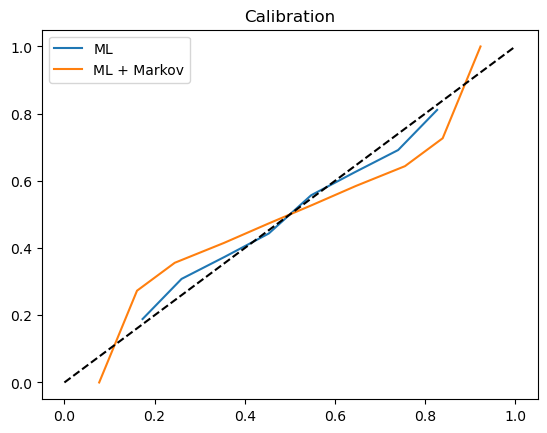

In [109]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

p_true_ml, p_pred_ml = calibration_curve(y_true, y_pred_ml, n_bins=10)
p_true_mk, p_pred_mk = calibration_curve(y_true, y_pred_markov, n_bins=10)

plt.plot(p_pred_ml, p_true_ml, label="ML")
plt.plot(p_pred_mk, p_true_mk, label="ML + Markov")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("Calibration")
plt.show()

In [110]:
### At what point does using Markov chain model improve results???? #### 
### Use in play data + Markov approach, then compare to live odds to dentify opportunities?? ###

In [195]:
max(elo_dict)
max(elo_dict, key=elo_dict.get)

'David Goffin'

In [197]:
elo_dict['David Goffin']

1832.4132111192405